In [1]:
from catboost import CatBoostClassifier
from sklearn.metrics import recall_score,accuracy_score,confusion_matrix,precision_score,f1_score,roc_curve,auc,multilabel_confusion_matrix
import pandas as pd
import optuna
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X_train=pd.read_csv(r"D:\ML Project\Data Splits\X_train.csv")
X_val=pd.read_csv(r"D:\ML Project\Data Splits\X_val.csv")
X_test=pd.read_csv(r"D:\ML Project\Data Splits\X_test.csv")

Y_train=pd.read_csv(r"D:\ML Project\Data Splits\Y_train.csv")['class']
Y_val=pd.read_csv(r"D:\ML Project\Data Splits\Y_val.csv")['class']
Y_test=pd.read_csv(r"D:\ML Project\Data Splits\Y_test.csv")['class']

In [3]:
# iterations = list(range(50,850,50))
# learning_rate = [round(x, 2) for x in np.arange(0.1, 0.5, 0.01)]
# depth = list(range(3, 11))
# l2_leaf_reg = list(range(1,11,1))

In [4]:
def objective(trial):
    iterations=trial.suggest_int('iterations',100,800)
    learning_rate=trial.suggest_float('learning_rate',0.1,0.5)
    depth=trial.suggest_int('depth',3,10)
    l2_leaf_reg=trial.suggest_int('l2_leaf_reg',1,10)

    model=CatBoostClassifier(iterations=iterations,learning_rate=learning_rate,depth=depth,l2_leaf_reg=l2_leaf_reg,random_state=50)
    model.fit(X_train,Y_train)
    Y_val_pred=model.predict(X_val)
    accuracy_val=accuracy_score(Y_val,Y_val_pred)

    return accuracy_val


study=optuna.create_study(direction='maximize')
study.optimize(objective,n_trials=50)

# direction='maximize' since we are working on acuracy which needs to be maximized

[I 2026-05-25 12:41:52,275] A new study created in memory with name: no-name-1134ab2a-dd82-4d54-a7ff-e1d8a9d1350a


0:	learn: 0.5759814	total: 110ms	remaining: 49.6s
1:	learn: 0.3766976	total: 125ms	remaining: 28.2s
2:	learn: 0.2621859	total: 136ms	remaining: 20.4s
3:	learn: 0.1917943	total: 147ms	remaining: 16.6s
4:	learn: 0.1459592	total: 159ms	remaining: 14.2s
5:	learn: 0.1147285	total: 173ms	remaining: 12.9s
6:	learn: 0.0932501	total: 188ms	remaining: 12s
7:	learn: 0.0781617	total: 200ms	remaining: 11.1s
8:	learn: 0.0673765	total: 213ms	remaining: 10.5s
9:	learn: 0.0600865	total: 224ms	remaining: 9.92s
10:	learn: 0.0546816	total: 234ms	remaining: 9.42s
11:	learn: 0.0511434	total: 245ms	remaining: 9.01s
12:	learn: 0.0490388	total: 258ms	remaining: 8.72s
13:	learn: 0.0470220	total: 270ms	remaining: 8.47s
14:	learn: 0.0413502	total: 282ms	remaining: 8.25s
15:	learn: 0.0399228	total: 296ms	remaining: 8.09s
16:	learn: 0.0388410	total: 309ms	remaining: 7.93s
17:	learn: 0.0378552	total: 325ms	remaining: 7.85s
18:	learn: 0.0372334	total: 336ms	remaining: 7.69s
19:	learn: 0.0365209	total: 349ms	remaining

[I 2026-05-25 12:41:58,103] Trial 0 finished with value: 0.9915 and parameters: {'iterations': 453, 'learning_rate': 0.33403441508751086, 'depth': 4, 'l2_leaf_reg': 6}. Best is trial 0 with value: 0.9915.


452:	learn: 0.0169911	total: 5.54s	remaining: 0us
0:	learn: 0.9152901	total: 37.9ms	remaining: 29.7s
1:	learn: 0.7790401	total: 72ms	remaining: 28.2s
2:	learn: 0.6722714	total: 110ms	remaining: 28.7s
3:	learn: 0.5858961	total: 143ms	remaining: 27.9s
4:	learn: 0.5148885	total: 180ms	remaining: 28.1s
5:	learn: 0.4553815	total: 215ms	remaining: 27.9s
6:	learn: 0.4051121	total: 248ms	remaining: 27.6s
7:	learn: 0.3620104	total: 281ms	remaining: 27.2s
8:	learn: 0.3248990	total: 316ms	remaining: 27.2s
9:	learn: 0.2926648	total: 348ms	remaining: 27s
10:	learn: 0.2644506	total: 383ms	remaining: 26.9s
11:	learn: 0.2397759	total: 415ms	remaining: 26.7s
12:	learn: 0.2179950	total: 451ms	remaining: 26.8s
13:	learn: 0.1987801	total: 483ms	remaining: 26.6s
14:	learn: 0.1819418	total: 515ms	remaining: 26.4s
15:	learn: 0.1669071	total: 546ms	remaining: 26.2s
16:	learn: 0.1539729	total: 577ms	remaining: 26s
17:	learn: 0.1422549	total: 606ms	remaining: 25.8s
18:	learn: 0.1316083	total: 637ms	remaining: 2

[I 2026-05-25 12:42:24,370] Trial 1 finished with value: 0.992 and parameters: {'iterations': 785, 'learning_rate': 0.10167720669422886, 'depth': 7, 'l2_leaf_reg': 7}. Best is trial 1 with value: 0.992.


...

0:	learn: 0.5073661	total: 49.9ms	remaining: 33.3s
1:	learn: 0.3136237	total: 98.6ms	remaining: 32.8s
2:	learn: 0.2103596	total: 146ms	remaining: 32.4s
3:	learn: 0.1483012	total: 191ms	remaining: 31.7s
4:	learn: 0.1103484	total: 237ms	remaining: 31.4s
5:	learn: 0.0865827	total: 286ms	remaining: 31.5s
6:	learn: 0.0710347	total: 333ms	remaining: 31.4s
7:	learn: 0.0606924	total: 379ms	remaining: 31.2s
8:	learn: 0.0516556	total: 425ms	remaining: 31.1s
9:	learn: 0.0469815	total: 474ms	remaining: 31.1s
10:	learn: 0.0438668	total: 524ms	remaining: 31.2s
11:	learn: 0.0401182	total: 574ms	remaining: 31.3s
12:	learn: 0.0382723	total: 621ms	remaining: 31.2s
13:	learn: 0.0365590	total: 670ms	remaining: 31.2s
14:	learn: 0.0351392	total: 717ms	remaining: 31.2s
15:	learn: 0.0341167	total: 767ms	remaining: 31.2s
16:	learn: 0.0332572	total: 816ms	remaining: 31.2s
17:	learn: 0.0323254	total: 866ms	remaining: 31.2s
18:	learn: 0.0311844	total: 913ms	remaining: 31.1s
19:	learn: 0.0308040	total: 961ms	remai

[I 2026-05-25 12:57:39,084] Trial 48 finished with value: 0.992 and parameters: {'iterations': 667, 'learning_rate': 0.3966790542144061, 'depth': 8, 'l2_leaf_reg': 7}. Best is trial 24 with value: 0.9925.


665:	learn: 0.0050028	total: 33.2s	remaining: 49.8ms
666:	learn: 0.0049985	total: 33.2s	remaining: 0us
0:	learn: 0.7668771	total: 25.1ms	remaining: 19.2s
1:	learn: 0.5776062	total: 50.8ms	remaining: 19.4s
2:	learn: 0.4514207	total: 73.9ms	remaining: 18.8s
3:	learn: 0.3610405	total: 97.1ms	remaining: 18.5s
4:	learn: 0.2936505	total: 121ms	remaining: 18.4s
5:	learn: 0.2419658	total: 145ms	remaining: 18.4s
6:	learn: 0.2022618	total: 172ms	remaining: 18.6s
7:	learn: 0.1705302	total: 197ms	remaining: 18.7s
8:	learn: 0.1453537	total: 220ms	remaining: 18.6s
9:	learn: 0.1250874	total: 246ms	remaining: 18.6s
10:	learn: 0.1087938	total: 270ms	remaining: 18.6s
11:	learn: 0.0958826	total: 294ms	remaining: 18.5s
12:	learn: 0.0854048	total: 318ms	remaining: 18.4s
13:	learn: 0.0765041	total: 340ms	remaining: 18.3s
14:	learn: 0.0697600	total: 365ms	remaining: 18.3s
15:	learn: 0.0637929	total: 388ms	remaining: 18.2s
16:	learn: 0.0592966	total: 411ms	remaining: 18.1s
17:	learn: 0.0556636	total: 434ms	re

[I 2026-05-25 12:57:57,168] Trial 49 finished with value: 0.9914 and parameters: {'iterations': 767, 'learning_rate': 0.19240891945192443, 'depth': 7, 'l2_leaf_reg': 1}. Best is trial 24 with value: 0.9925.


766:	learn: 0.0029667	total: 17.8s	remaining: 0us


In [5]:
optuna_CB = study.trials_dataframe()
optuna_CB.to_csv(r"D:\ML Project\Model_Tuned_Parameter_data\Optuna_CB.csv", index=False)

In [6]:
with open(r"D:\ML Project\Model_Tuned_Parameter_data\Parameters\CB.json", "w") as f:
    input=study.best_trial.params
    input['Accuracy']=study.best_trial.value
    json.dump(input, f)

In [7]:
print(f'Validation best accuracy: {study.best_trial.value}')
print(f'Validation best parameters: {study.best_trial.params}')

Validation best accuracy: 0.9925
Validation best parameters: {'iterations': 794, 'learning_rate': 0.3314655795831053, 'depth': 6, 'l2_leaf_reg': 7}


In [8]:
with open(r"D:\ML Project\Model_Tuned_Parameter_data\Parameters\CB.json", "r") as f:
    loaded_dict = json.load(f)

params = dict(list(loaded_dict.items())[:-1])
validation_accuracy=loaded_dict['Accuracy']

In [9]:
model_best=CatBoostClassifier(**params,random_state=50)  # *8 unpacks the dictionary and allows us to pass the dictionary keys as keywords (parameter keywords) in the function

# Dictionary Unpacking in Function CallsThe ** operator allows you to take key-value pairs from a dictionary and pass them as named keyword arguments to a function. Experts on Stack Overflow explain that this enables dynamic argument handling.pythondef greet(name, age):
#     print(f"Hello {name}, you are {age} years old.")

# data = {"name": "Alice", "age": 25}
# greet(**data)  # Equivalent to greet(name="Alice", age=25)
# Use code with caution.3. Collecting Arguments (**kwargs)In a function definition, ** collects any number of keyword arguments into a single dictionary, typically named kwargs. A guide on Medium highlights how this provides a shortcut for accepting flexible inputs.pythondef show_info(**kwargs):
#     for key, value in kwargs.items():
#         print(f"{key}: {value}")

# show_info(city="New York", job="Developer") 
# # kwargs becomes {'city': 'New York', 'job': 'Developer'}
# Use code with caution.4. Merging Dictionaries (Python 3.5+)You can use ** inside a dictionary literal to merge multiple dictionaries into one.pythondict1 = {"a": 1}
# dict2 = {"b": 2}
# merged = {**dict1, **dict2}  # Output: {'a': 1, 'b': 2}


model_best.fit(X_train,Y_train)

0:	learn: 0.5782086	total: 19.4ms	remaining: 15.4s
1:	learn: 0.3772645	total: 37.6ms	remaining: 14.9s
2:	learn: 0.2628516	total: 55.3ms	remaining: 14.6s
3:	learn: 0.1919796	total: 71.9ms	remaining: 14.2s
4:	learn: 0.1446974	total: 91.2ms	remaining: 14.4s
5:	learn: 0.1134778	total: 110ms	remaining: 14.4s
6:	learn: 0.0918145	total: 129ms	remaining: 14.5s
7:	learn: 0.0771437	total: 146ms	remaining: 14.4s
8:	learn: 0.0667465	total: 164ms	remaining: 14.3s
9:	learn: 0.0594619	total: 181ms	remaining: 14.2s
10:	learn: 0.0542887	total: 199ms	remaining: 14.2s
11:	learn: 0.0463570	total: 217ms	remaining: 14.2s
12:	learn: 0.0430488	total: 236ms	remaining: 14.2s
13:	learn: 0.0408665	total: 256ms	remaining: 14.3s
14:	learn: 0.0391210	total: 274ms	remaining: 14.2s
15:	learn: 0.0378344	total: 292ms	remaining: 14.2s
16:	learn: 0.0365523	total: 308ms	remaining: 14.1s
17:	learn: 0.0357538	total: 327ms	remaining: 14.1s
18:	learn: 0.0348948	total: 344ms	remaining: 14.1s
19:	learn: 0.0341886	total: 361ms	re

CatBoostClassifier(depth=6, iterations=794, l2_leaf_reg=7, learning_rate=0.3314655795831053, random_state=50)

In [10]:
Y_train_pred=model_best.predict(X_train)

Accuracy_train=accuracy_score(Y_train,Y_train_pred)

Accuracy_train       # Train Accuracy

0.9979125

## Test Set Analysis ###########

In [11]:
Y_test_pred=model_best.predict(X_test)

In [12]:
Accuracy_test=accuracy_score(Y_test,Y_test_pred)
Accuracy_test                                 # Test Accuracy

0.9919

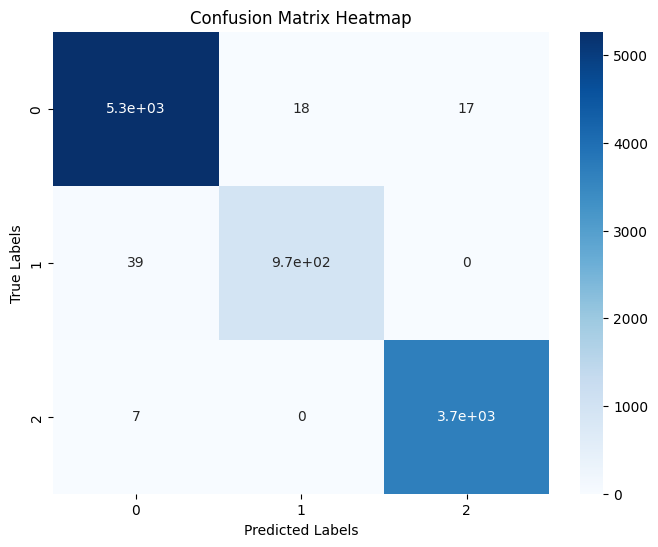

In [13]:
conf_matrix=confusion_matrix(Y_test,Y_test_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix,annot=True,cmap='Blues')

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [14]:
### Recall

Macro_average_recall=recall_score(Y_test,Y_test_pred,average='macro')
Per_class_recall=recall_score(Y_test,Y_test_pred,average=None)

Macro_average_recall   ## Macro Recall and accuracy both are high. So class imbalance is not a problem

0.9842455973466896

In [15]:
Per_class_recall    ## Class imbalance is not an issue as per recall since per class recall for all 3 classes is very high.

array([0.99340121, 0.9612326 , 0.99810298])

In [16]:
## Precision

Macro_average_precision=precision_score(Y_test,Y_test_pred,average='macro')
Per_class_precision=precision_score(Y_test,Y_test_pred,average=None)

Macro_average_precision   ## Macro Average Precision is also very high

0.9894921810082428

In [17]:
Per_class_precision  ## Even per class precision is also very high

array([0.99134525, 0.98172589, 0.99540541])

In [18]:
## F1 score

Macro_average_f1_score=f1_score(Y_test,Y_test_pred,average='macro')
Per_class_f1_score=f1_score(Y_test,Y_test_pred,average=None)

Macro_average_f1_score   ## Macro Average Precision is also very high

0.9868319004783404

In [19]:
Per_class_f1_score

array([0.99237216, 0.97137117, 0.99675237])

In [20]:
## Sensitivity and Specificity

mcm = multilabel_confusion_matrix(Y_test,Y_test_pred)

tn = mcm[:, 0, 0]
fp = mcm[:, 0, 1]
fn = mcm[:, 1, 0]
tp = mcm[:, 1, 1]

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

sensitivity

array([0.99340121, 0.9612326 , 0.99810298])

In [21]:
specificity

array([0.99020443, 0.99799867, 0.99730586])

In [22]:
Metrics={'Training Accuracy':Accuracy_train,'Validation Accuracy (Post Optuna Tuning)':validation_accuracy,'Test Accuracy':Accuracy_test,'Macro Average Recall':Macro_average_recall,
         'Per Class Recall':Per_class_recall,'Macro Average Precision':Macro_average_precision,'Per Class Precision':Per_class_precision,'Macro Average F1 Score':Macro_average_f1_score,
         'Per Class F1 Score':Per_class_f1_score,'Sensitivity':sensitivity,'Specificity':specificity}

Metrics=pd.Series(Metrics)

In [23]:
Metrics

Training Accuracy                                                                    0.997912
Validation Accuracy (Post Optuna Tuning)                                               0.9925
Test Accuracy                                                                          0.9919
Macro Average Recall                                                                 0.984246
Per Class Recall                            [0.9934012066365008, 0.9612326043737575, 0.998...
Macro Average Precision                                                              0.989492
Per Class Precision                         [0.9913452492944497, 0.9817258883248731, 0.995...
Macro Average F1 Score                                                               0.986832
Per Class F1 Score                          [0.9923721631038704, 0.9713711702661979, 0.996...
Sensitivity                                 [0.9934012066365008, 0.9612326043737575, 0.998...
Specificity                                 [0.9902044293015

In [24]:
Metrics.to_csv(r'D:\ML Project\Model_Metrics\CatBoost.csv',header=False)